# Naive Quaternion Fitting using B-Spline in Euclidean Space

Simple approximation of quaternion sequences by LSPIA using B-Spline on euclidean basis and re-normalization.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from src.utils import prepare_clip

import src.cagd.solver as solver
import src.cagd.manifold as manifold
import src.cagd.param as param
import src.cagd.knot_topo as knot_topo
import src.cagd.cps_init as cps_init
import src.cagd.knot_optim as knot_optim 
# import src.cagd.time_optim as time_optim
import src.cagd.processors as processors

from src.compress import MoCapCompressor, TrackCategorizer
from src.eval import summarize_compression_info, body_parts_plot, per_frame_errors

from src.viz.animate import AnimatedSkeletonsPlotter
from src.viz.static import StaticTrajectoriesPLotter
from src.kinematics import forward_kinematics

---
## Load Test Clip

In [3]:
data = np.load("data/npz/clip_72.npz", allow_pickle=True)
clip = data["clip"].item()
parsed_clip, clip_name, clip_quats = prepare_clip(clip)
clip_pos = forward_kinematics(clip_quats)

# AnimatedSkeletonsPlotter(title=clip_name).apply_defualt_layout().add_skeleton_frames(clip_pos).show()

---
## Compression (Approximation)

In [24]:
_space      = manifold.QuaternionSpace()
_param      = param.CentripetalParameterizer(power=0.5)
_init       = cps_init.GrevilleAbscissaSampler(num_initial_control_pts=20)
_knot_topo  = knot_topo.CurvatureDistributeKnots(base_density=1e-4, smoothing_window=3, enable_boehm=True, knot_insertion_tolerance=1e-3) 
_knot_optim = knot_optim.SpringMassKnotShifter(learning_rate=1e-3, min_span_ratio=1e-6)
_time_optim = None

fit_solver = solver.LSPIASolver(
    degree     = 2,
    space      = _space,
    param      = _param,
    init       = _init,
    knot_topo  = _knot_topo,
    knot_optim = _knot_optim,
    time_optim = _time_optim,
    )

fit_params = dict(
    macro_step    = 20,
    max_iters     = 1000,
    converge_iter = 25, 
    tolerance     = 5e-4,
    verbose       = False,
    print_every   = 10,
    err_agg_func  = np.max,
)

track_cate = TrackCategorizer(
    threshold_deg = 3.0,
    dist_agg_func = np.max,
)

compressor = MoCapCompressor(
    track_cate = track_cate,
    compress_preprocessors = [processors.AntipodalAlignmentProcessor()],
    decompress_postprocessors = [processors.NomalizeProcessor()],
)

In [25]:
compressed_quats, compression_info = compressor.compress(clip_quats, fit_solver, **fit_params)

---
## Decompression

In [26]:
decompressed_quats = compressor.decompress(compressed_quats)

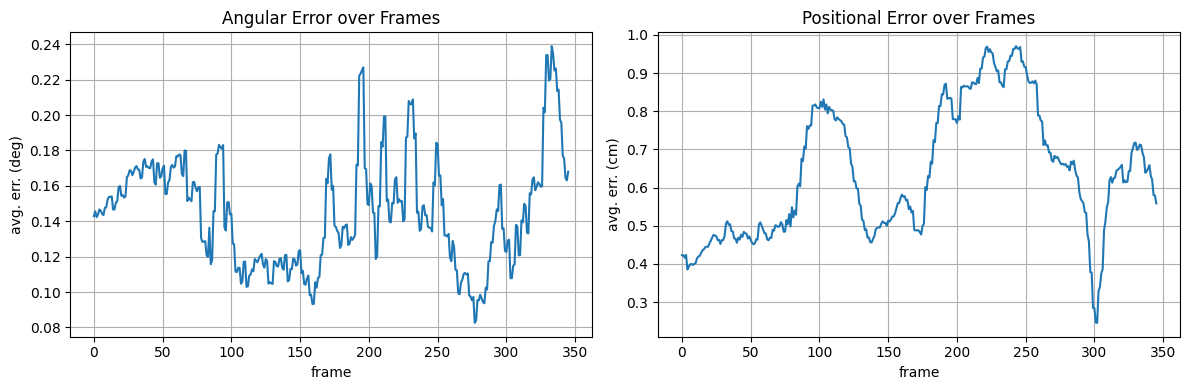

In [27]:
errors = per_frame_errors(clip_quats, decompressed_quats)

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axs[0].plot(np.arange(len(errors["angular"])), np.rad2deg(errors["angular"]))
axs[0].set_title("Angular Error over Frames")
axs[0].set_ylabel("avg. err. (deg)")
axs[0].set_xlabel("frame")
axs[0].grid()

axs[1].plot(np.arange(len(errors["positional"])), 100 * errors["positional"])
axs[1].set_title("Positional Error over Frames")
axs[1].set_ylabel("avg. err. (cm)")
axs[1].set_xlabel("frame")
axs[1].grid()

fig.tight_layout()
plt.show()

In [28]:
approx_pos = forward_kinematics(decompressed_quats)

(
    AnimatedSkeletonsPlotter(title="GT vs. APPROX", stride=3)
    .apply_defualt_layout()
    .add_skeleton_frames(clip_pos  , joints_color="black", bones_color="blue", name="GT")
    .add_skeleton_frames(approx_pos, joints_color="black", bones_color="red" , name="APPROX")
    .show()
)

---
## Evaluation

In [29]:
summary_info = summarize_compression_info(clip_quats, compressed_quats, compression_info)
summary_info.head()

,compression_type,final_error,num_iterations,num_control_pts,num_knots,num_data_time,total_used_floats,total_used_floats_raw,compression_ratio
rootx,singular,1.308452,1,1,0,1,5,1384,276.8
spine_01x,singular,0.901709,1,1,0,1,5,1384,276.8
spine_02x,singular,1.8035,1,1,0,1,5,1384,276.8
neckx,bspline,0.00099,93,42,45,346,559,1384,2.47585
headx,bspline,0.002231,28,32,35,346,509,1384,2.719057


### Evaluation of Compression Performance

In [30]:
ratio = summary_info["total_used_floats_raw"].sum() / summary_info["total_used_floats"].sum()
saved = (1.0 - 1.0 / ratio) * 100

print("Compression Summary")
print(f"-> Total floats used in original data   = {summary_info["total_used_floats_raw"].sum():,}")
print(f"-> Total floats used in compressed data = {summary_info["total_used_floats"].sum():,}")
print(f"-> Compression Ratio = {ratio:.6f} ({saved:.3f}% saved)")

Compression Summary
-> Total floats used in original data   = 65,048
-> Total floats used in compressed data = 27,347
-> Compression Ratio = 2.378616 (57.959% saved)


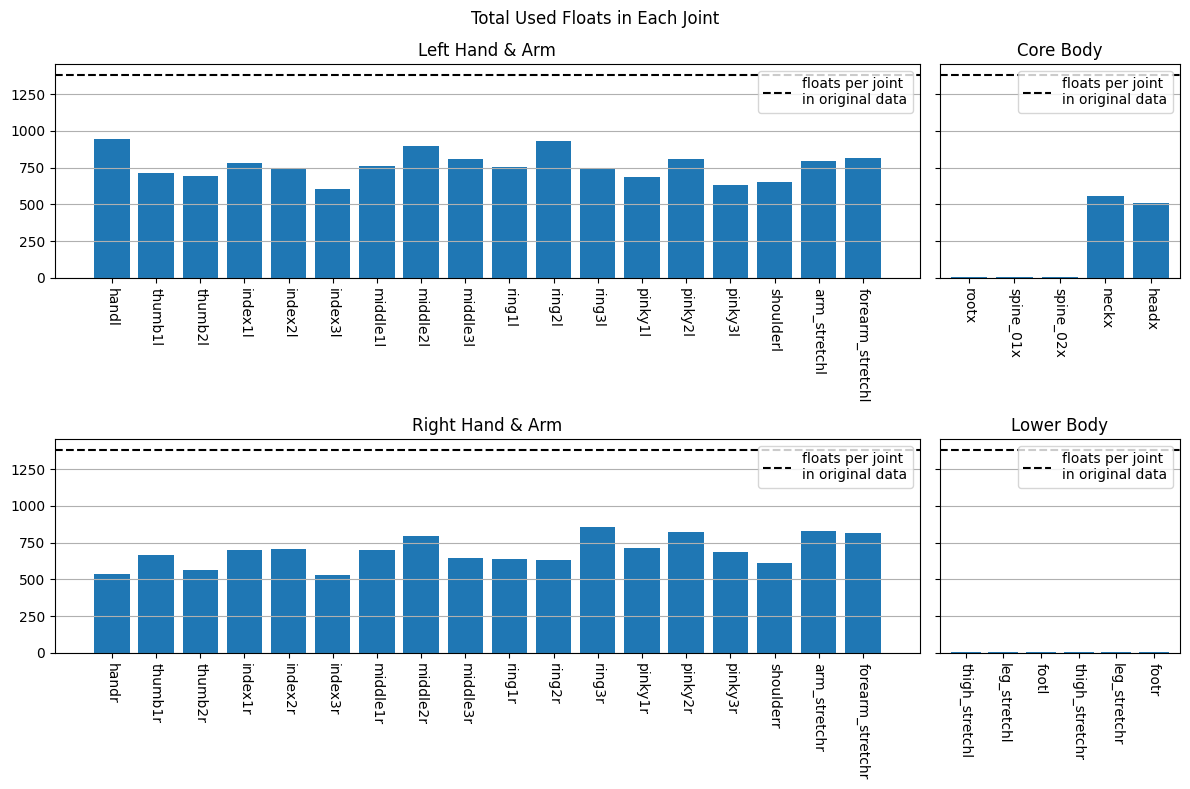

In [31]:
body_parts_plot(
    summary_info["total_used_floats"], title="Total Used Floats in Each Joint",
    hline=summary_info.loc["rootx"]["total_used_floats_raw"], hline_label="floats per joint\nin original data",
    )

### Evaluation of LSPIA Process

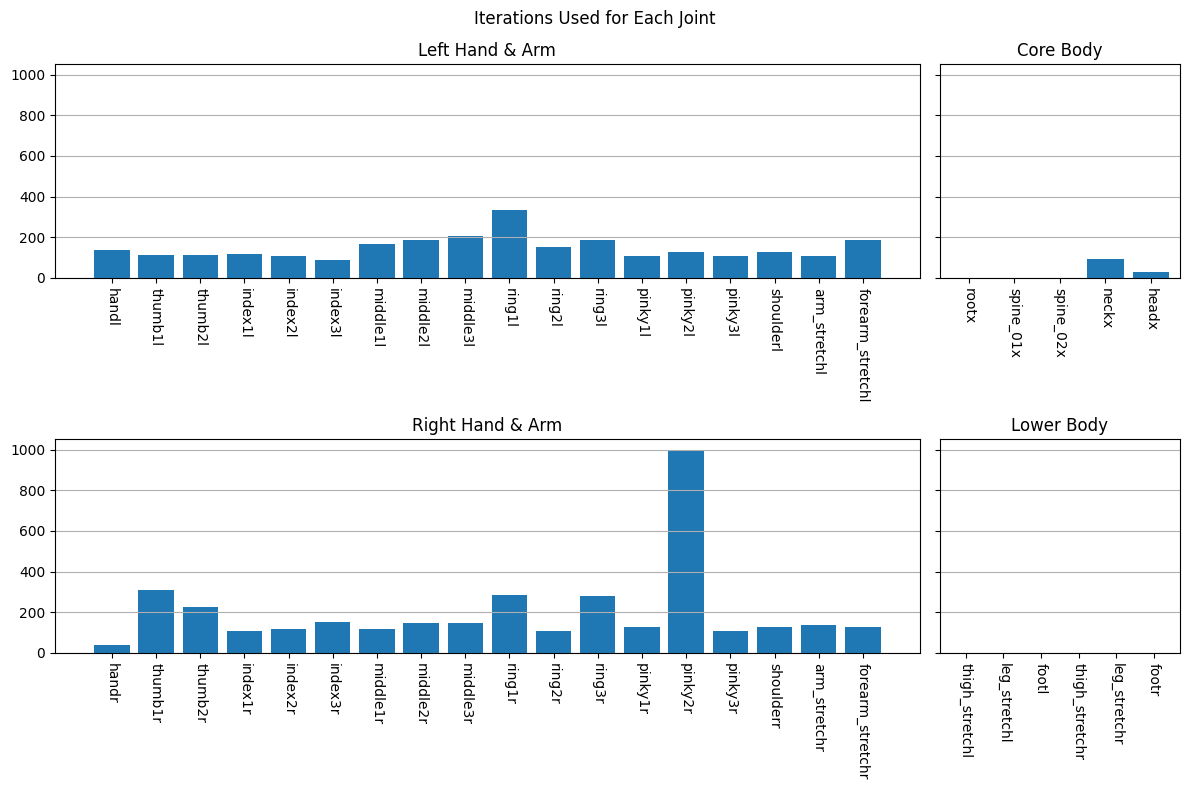

In [32]:
body_parts_plot(summary_info["num_iterations"], title="Iterations Used for Each Joint")

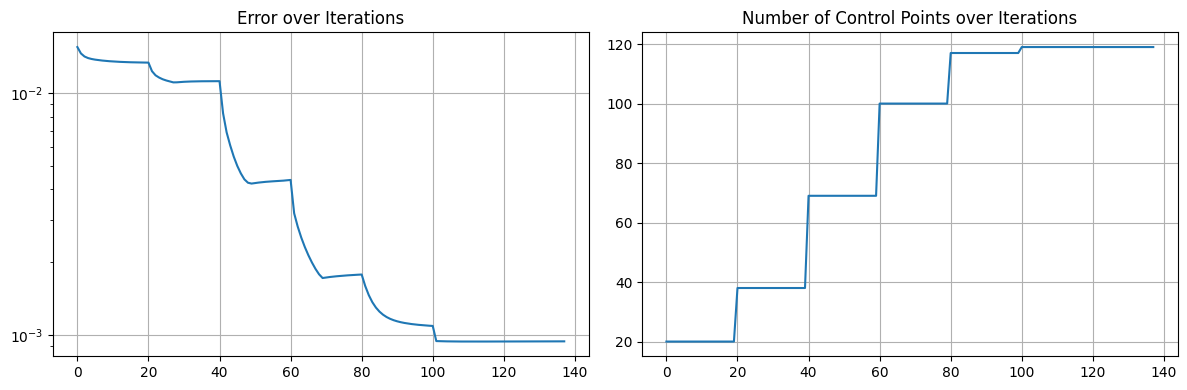

In [33]:
joint = "handl"
error = compression_info["error"][joint]
num_cps = compression_info["num_control_pts"][joint]

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axs[0].plot(error)
axs[0].set_yscale('log')
axs[0].grid()
axs[0].set_title("Error over Iterations")

axs[1].plot(num_cps)
axs[1].grid()
axs[1].set_title("Number of Control Points over Iterations")

fig.tight_layout()
plt.show()